# Análisis de un Accidente Marítimo con Python, Spark y Datos Geoespaciales

<div style="text-align: right; font-size: 28px">Libertad Chapinal y Álvaro Gutiérrez</div>

<img src="https://static.grupojoly.com/clip/78592e20-9e34-4240-8f57-c2639fccdcdf_16-9-aspect-ratio_1600w_0.webp" />
<div style="text-align: center">Buque "OS 35" en el fondeadero este, en junio de 2023. Fuente: EuropaSur</div>

<img width="1000px" border="1"  src="https://pycon25.s3.eu-west-1.amazonaws.com/imgs/el+diario.png"/>

<img width="1000px" border="1"  src="https://pycon25.s3.eu-west-1.amazonaws.com/imgs/Elpais.png"/>

<img width="1000px" border="1"  src="https://pycon25.s3.eu-west-1.amazonaws.com/imgs/NoticiaGibraltar.png"/>

# 🚢 Puerto de Algeciras

El Puerto de Algeciras es el **principal puerto de España** y uno de los más importantes de Europa debido a su ubicación estratégica en el Estrecho de Gibraltar.

![Imagen Puerto Algeciras: Mapa Base Satelital ArcGIS](https://pycon25.s3.eu-west-1.amazonaws.com/imgs/SatelitalPuerto.png)

## Datos sobre el puerto

### 📚 Importación de bibliotecas

In [3]:
from pyspark.sql import functions as F
from pyspark.sql import Row
from pyspark.sql.functions import *
from pyspark.sql.types import StringType
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import unicodedata
import builtins

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

### 🛟 Datos de Puertos del Estado

[Fuente de los datos: Puertos del Estado](https://www.puertos.es/datos/estadisticas/anuales)

In [ ]:
df_puertos = spark.read \
    .option("header", "true") \
    .option("delimiter", ";") \
    .csv("s3://pycon25/datasets/XXXX/Mercancias-Puertos.csv")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [3]:
df_puertos.show(2, truncate=False, vertical=True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

-RECORD 0--------------------------------------------
 Año                             | 1962              
 Autoridad Portuaria             | A Coruña          
 Operacion                       | Desembarque       
 Transito                        | Incluido tránsito 
 Graneles líquidos               | 204.092           
 Graneles sólidos                | 147.137           
 Mercancía general convencional  | 110.979           
 Mercancía general en contenedor | 0                 
 Mercancía general               | 110.979           
 Pesca                           | 71.917            
 Avituallamiento                 | 0                 
 Tráfico interior                | 6.319             
 TRÁFICO TOTAL                   | 540.444           
 _c13                            | NULL              
 _c14                            | NULL              
 _c15                            | NULL              
-RECORD 1--------------------------------------------
 Año                        

### 🧹 Preparación de los datos

In [5]:
def clean_col_name(name):
    name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('utf-8')
    name = name.replace(" ", "_").replace("-", "_")
    name = ''.join(c for c in name if c.isalnum() or c == "_")
    return name

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [6]:
def remove_accents(text):
    if text is not None:
        return ''.join(
            c for c in unicodedata.normalize('NFD', text)
            if unicodedata.category(c) != 'Mn'
        )
    return None

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [7]:
df_puertos = df_puertos.toDF(*[clean_col_name(c) for c in df_puertos.columns])

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [8]:
cols = [
    "TRAFICO_TOTAL",
    "Graneles_liquidos",
    "Graneles_solidos",
    "Mercancia_general_convencional",
    "Mercancia_general_en_contenedor",
    "Mercancia_general",
    "Pesca",
    "Avituallamiento",
    "Trafico_interior"
]

for c in cols:
    df_puertos = df_puertos.withColumn(c, F.regexp_replace(F.col(c), r"\.", ""))



VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [9]:
remove_accents_udf = udf(remove_accents, StringType())   
df_puertos = (
    df_puertos
    .withColumn("Autoridad_Portuaria", F.regexp_replace(F.col("Autoridad_Portuaria"), " ", "_"))
    .withColumn("Autoridad_Portuaria", remove_accents_udf(col("Autoridad_Portuaria")))
    .withColumn("Transito", F.regexp_replace(F.col("Transito"), " ", "_"))
    .withColumn("Transito", remove_accents_udf(col("Transito")))
)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [10]:
df_puertos.show(2, truncate=False, vertical=True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

-RECORD 0--------------------------------------------
 Ano                             | 1962              
 Autoridad_Portuaria             | A_Coruna          
 Operacion                       | Desembarque       
 Transito                        | Incluido_transito 
 Graneles_liquidos               | 204092            
 Graneles_solidos                | 147137            
 Mercancia_general_convencional  | 110979            
 Mercancia_general_en_contenedor | 0                 
 Mercancia_general               | 110979            
 Pesca                           | 71917             
 Avituallamiento                 | 0                 
 Trafico_interior                | 6319              
 TRAFICO_TOTAL                   | 540444            
 _c13                            | NULL              
 _c14                            | NULL              
 _c15                            | NULL              
-RECORD 1--------------------------------------------
 Ano                        

In [11]:
df_puertos.createOrReplaceTempView('Puertos')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [12]:
df_sorted = spark.sql("SELECT Autoridad_Portuaria, Ano, SUM(TRAFICO_TOTAL) AS total_trafico FROM Puertos  WHERE Operacion IN ('Embarque', 'Desembarque') AND Transito = 'Incluido_transito' GROUP BY Autoridad_Portuaria, Ano ORDER BY Autoridad_Portuaria, Ano;")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [13]:
df_sorted.show(12)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-------------------+----+-------------+
|Autoridad_Portuaria| Ano|total_trafico|
+-------------------+----+-------------+
|           A_Coruna|1962|    1199365.0|
|           A_Coruna|1963|    1291040.0|
|           A_Coruna|1964|    4040887.0|
|           A_Coruna|1965|    4632138.0|
|           A_Coruna|1966|    5090275.0|
|           A_Coruna|1967|    5025986.0|
|           A_Coruna|1968|    5564871.0|
|           A_Coruna|1969|    5707998.0|
|           A_Coruna|1970|    7159172.0|
|           A_Coruna|1971|    7611089.0|
|           A_Coruna|1972|    8251954.0|
|           A_Coruna|1973|    7674463.0|
+-------------------+----+-------------+
only showing top 12 rows

In [14]:
df_sorted.createOrReplaceTempView('MercanciaPortuariaAnual')

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [15]:
df_2022 = spark.sql("SELECT * FROM MERCANCIAPORTUARIAANUAL WHERE Ano = 2022").toPandas()
df_2022_sorted = df_2022.sort_values('total_trafico',ascending=True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

### 📊 Visualización: Puerto de Algeciras

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

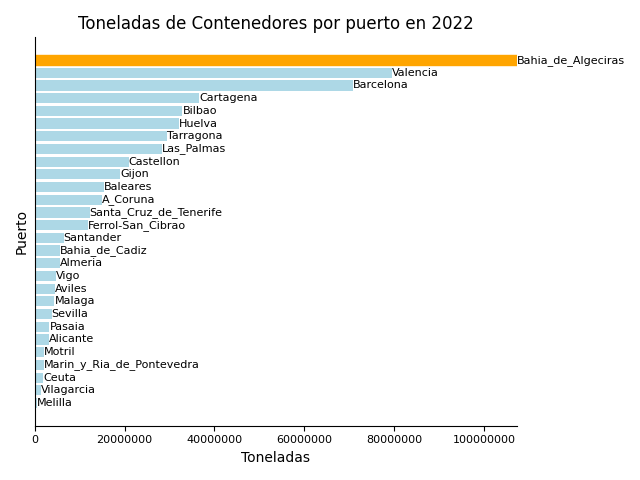

In [16]:
fig, ax = plt.subplots()
ax.barh(df_2022_sorted["Autoridad_Portuaria"], df_2022_sorted["total_trafico"],color='lightblue')

barras = ax.patches
barras[27].set_color('orange')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, (bar, label) in enumerate(zip(barras, df_2022_sorted["Autoridad_Portuaria"])):
    ancho = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2 
    ax.text(ancho, y, label, va='center', ha='left',fontsize=8)
    
# Cambiar el formato de las etiquetas del eje X
ax.tick_params(axis='x', labelsize=8, labelrotation=0)

# Usar formato de porcentaje
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))
    
max_valor = builtins.max(df_2022_sorted["total_trafico"])
ax.set_xlim(0, max_valor + 30)

ax.set_yticklabels([])
ax.set_yticks([])
plt.title('Toneladas de Contenedores por puerto en 2022')
ax.set_xlabel('Toneladas')
ax.set_ylabel('Puerto')

plt.tight_layout()


%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

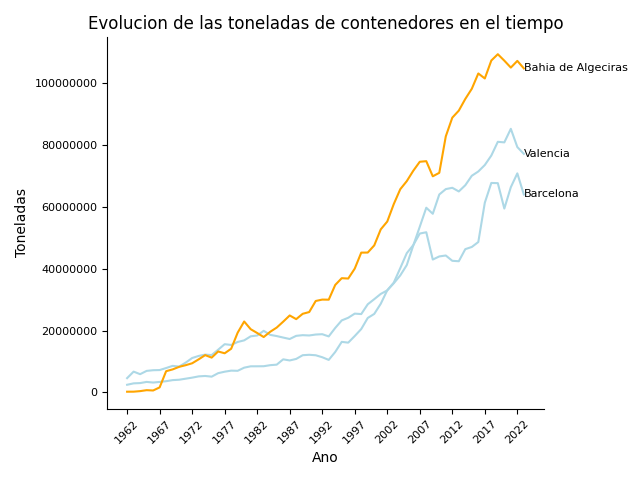

In [18]:
df_algeciras = spark.sql("SELECT * FROM MERCANCIAPORTUARIAANUAL WHERE Autoridad_Portuaria = 'Bahia_de_Algeciras'").toPandas()
df_valencia = spark.sql("SELECT * FROM MERCANCIAPORTUARIAANUAL WHERE Autoridad_Portuaria = 'Valencia'").toPandas()
df_barcelona = spark.sql("SELECT * FROM MERCANCIAPORTUARIAANUAL WHERE Autoridad_Portuaria = 'Barcelona'").toPandas()

fig, ax = plt.subplots()
ax.plot(df_valencia['Ano'],df_valencia['total_trafico'],color='lightblue')
ax.plot(df_barcelona['Ano'],df_barcelona['total_trafico'],color='lightblue')
ax.plot(df_algeciras['Ano'],df_algeciras['total_trafico'],color='orange')

ax.tick_params(axis='y', labelsize=8, labelrotation=0)
ax.tick_params(axis='x', labelsize=8, labelrotation=45)
ticks = ax.get_xticks()
ax.set_xticks(ticks[::5])
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))

ax.text(df_valencia['Ano'][61], df_valencia['total_trafico'][61], 'Valencia', fontsize=8, ha='left', va='center')
ax.text(df_barcelona['Ano'][61], df_barcelona['total_trafico'][61], 'Barcelona', fontsize=8, ha='left', va='center')
ax.text(df_algeciras['Ano'][61], df_algeciras['total_trafico'][61], 'Bahia de Algeciras', fontsize=8, ha='left', va='center')


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Evolucion de las toneladas de contenedores en el tiempo')
ax.set_xlabel('Ano')
ax.set_ylabel('Toneladas')

plt.tight_layout()

%matplot plt

# 🛰️ Sistema AIS

El sistema AIS (Automatic Identification System) es una tecnología marítima que permite a los barcos transmitir y recibir información de identificación y navegación, como su posición, rumbo y velocidad, para mejorar la seguridad y evitar colisiones.

<img src="https://datos-tecnologia.s3.eu-west-1.amazonaws.com/ais.png" />

En este caso nuestro proveedor de datos es [Spire](https://spire.com/)

## 🗓️ Acceso a los datos de AIS 
Del 29 de agosto al 2 de septiembre de 2022

In [ ]:
df = spark.read \
    .option("header", "true") \
    .option("delimiter", ",") \
    .csv("s3a://ga-engine-esri-es/datasetGibraltar/XXXXX/*.csv")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [20]:
df.count()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

2487732

### 🏗️ Arquitectura

![Imagen Arquitectura del Proyecto con todos los componentes](https://pycon25.s3.eu-west-1.amazonaws.com/imgs/Arquitectura.png)

## 🌐 Datos espaciales 

In [19]:
df.show(1, truncate=False,vertical = True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

-RECORD 0---------------------------------------------
 created_at          | 2022-09-01 09:28:19.917002 UTC 
 timestamp           | 2022-09-01 09:28:19 UTC        
 static_updated_at   | NULL                           
 position_updated_at | 2022-09-01 09:28:19 UTC        
 mmsi                | 970020804                      
 latitude            | 36.14579                       
 longitude           | -5.4293283333333333            
 speed               | 0                              
 course              | 0                              
 heading             | 511                            
 imo                 | NULL                           
 name                | NULL                           
 call_sign           | NULL                           
 flag                | NULL                           
 draught             | NULL                           
 ship_and_cargo_type | NULL                           
 ship_type           | NULL                           
 length   

In [20]:
df.printSchema()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- created_at: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- static_updated_at: string (nullable = true)
 |-- position_updated_at: string (nullable = true)
 |-- mmsi: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- speed: string (nullable = true)
 |-- course: string (nullable = true)
 |-- heading: string (nullable = true)
 |-- imo: string (nullable = true)
 |-- name: string (nullable = true)
 |-- call_sign: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- draught: string (nullable = true)
 |-- ship_and_cargo_type: string (nullable = true)
 |-- ship_type: string (nullable = true)
 |-- length: string (nullable = true)
 |-- width: string (nullable = true)
 |-- eta: string (nullable = true)
 |-- destination: string (nullable = true)
 |-- status: string (nullable = true)
 |-- collection_type: string (nullable = true)

## 🌍 ArcGIS GeoAnalytics Engine

<img width="600px" src="https://pycon25.s3.eu-west-1.amazonaws.com/imgs/esri.png"/>

- Biblioteca de funciones espaciales
- Construida sobre Apache Spark
- Procesamiento distribuido
- Escalable

In [21]:
import geoanalytics

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [ ]:
username=*****
password=******

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

#### 🚀 Acceso a la biblioteca geoespacial

In [23]:
geoanalytics.auth(username=username, password=password)
print('La version de GeoAnalytics Engine es: ', geoanalytics.version())

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

La version de GeoAnalytics Engine es:  1.6.0.3476

## 🤓 Corrección de los datos espaciales

<h4> 🗾 Coordenadas geográficas || Coordenadas proyectadas</h4>

<img src="https://pro.arcgis.com/en/pro-app/latest/help/mapping/properties/GUID-70E253E7-407E-469E-91DA-975B382EA6C9-web.png" />

In [24]:
df_geometria = df.selectExpr("*", "ST_Point(Longitude, Latitude, 4326) as SHAPE")\
    .st.set_geometry_field("SHAPE")\
    .withColumn("timestamp", to_timestamp(col('created_at').substr(1, 19), "yyyy-MM-dd HH:mm:ss")).st.set_time_fields("timestamp")

df_proyectadas = df_geometria.withColumn("SHAPE", geoanalytics.sql.functions.transform("SHAPE", 3857))

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [25]:
df_proyectadas.show(1, truncate=False,vertical = True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

-RECORD 0-------------------------------------------------------------
 created_at          | 2022-09-01 09:28:19.917002 UTC                 
 timestamp           | 2022-09-01 09:28:19                            
 static_updated_at   | NULL                                           
 position_updated_at | 2022-09-01 09:28:19 UTC                        
 mmsi                | 970020804                                      
 latitude            | 36.14579                                       
 longitude           | -5.4293283333333333                            
 speed               | 0                                              
 course              | 0                                              
 heading             | 511                                            
 imo                 | NULL                                           
 name                | NULL                                           
 call_sign           | NULL                                           
 flag 

In [26]:
df_proyectadas.printSchema()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- created_at: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- static_updated_at: string (nullable = true)
 |-- position_updated_at: string (nullable = true)
 |-- mmsi: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- speed: string (nullable = true)
 |-- course: string (nullable = true)
 |-- heading: string (nullable = true)
 |-- imo: string (nullable = true)
 |-- name: string (nullable = true)
 |-- call_sign: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- draught: string (nullable = true)
 |-- ship_and_cargo_type: string (nullable = true)
 |-- ship_type: string (nullable = true)
 |-- length: string (nullable = true)
 |-- width: string (nullable = true)
 |-- eta: string (nullable = true)
 |-- destination: string (nullable = true)
 |-- status: string (nullable = true)
 |-- collection_type: string (nullable = true)
 |-- SHAPE: point (nullable = true)

## 🗺️  Visualización de los datos

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

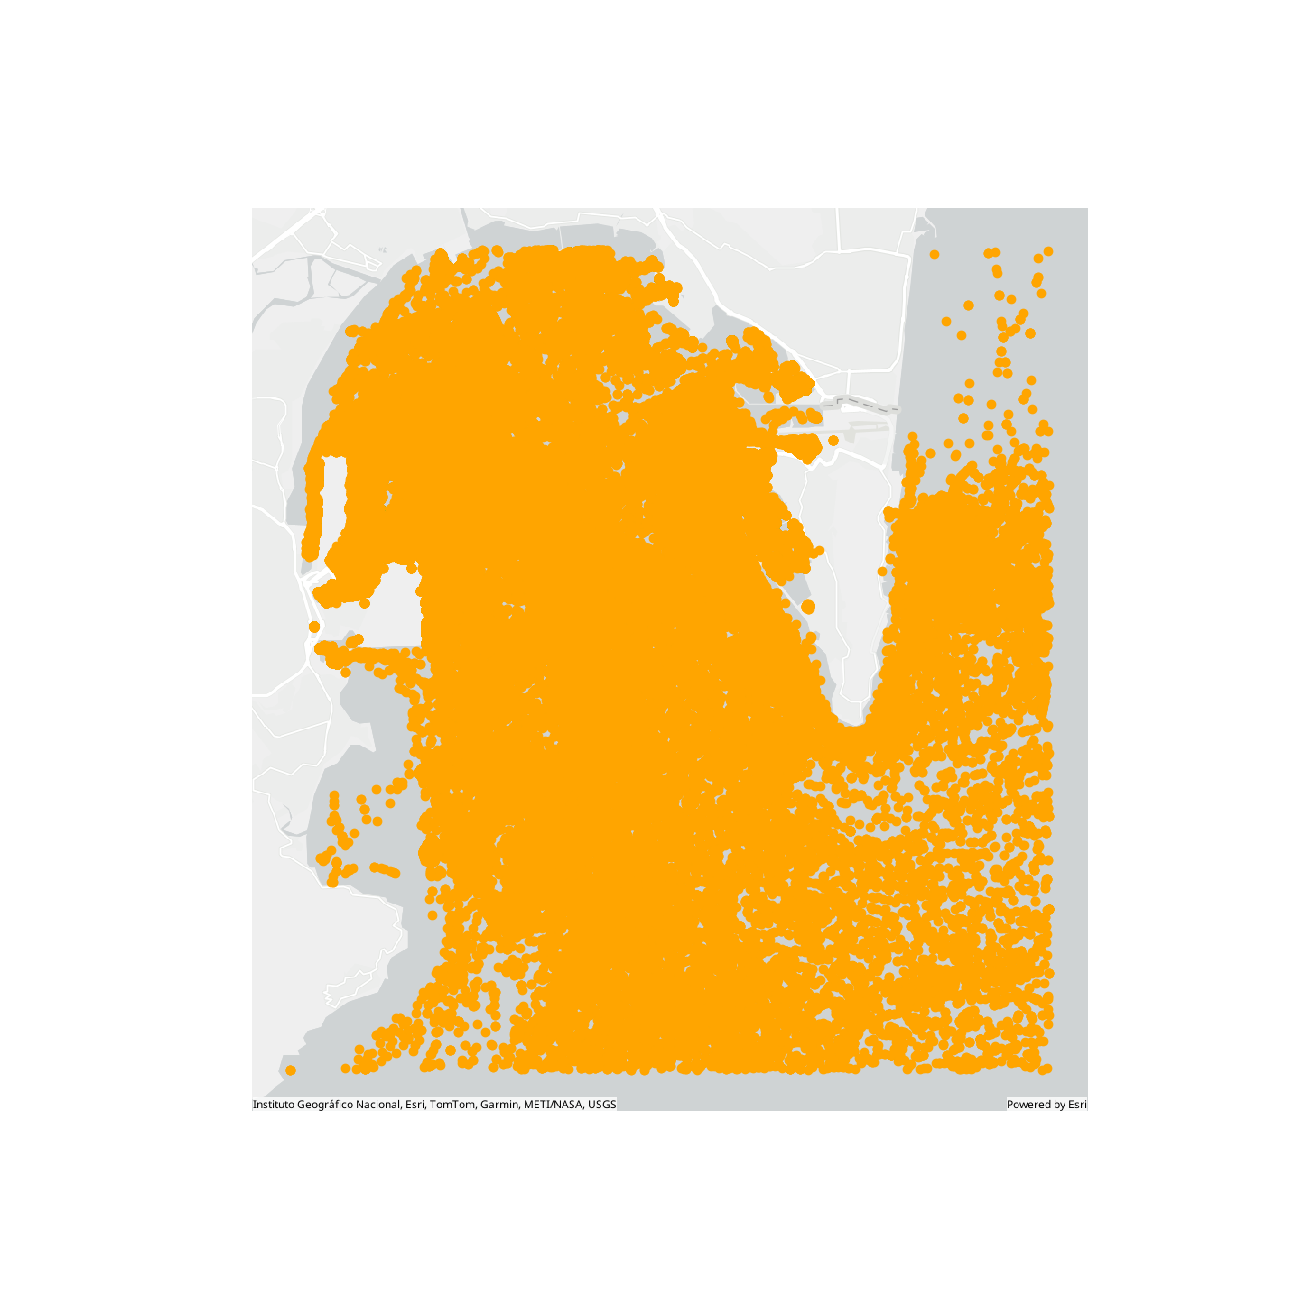

In [27]:
mapa_general = df_proyectadas.st.plot(
                        facecolor="orange",
                        figsize=(13, 13), 
                        legend=True, 
                        legend_kwds={"label": "Total posiciones barcos"},
                        basemap="light")

mapa_general.set(xlim=(-607588.9895384323, -590124.1438954463), 
         ylim=(4307100.0, 4326900.0), 
         frame_on=False,
         xticks=[],
         yticks=[])

%matplot plt

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

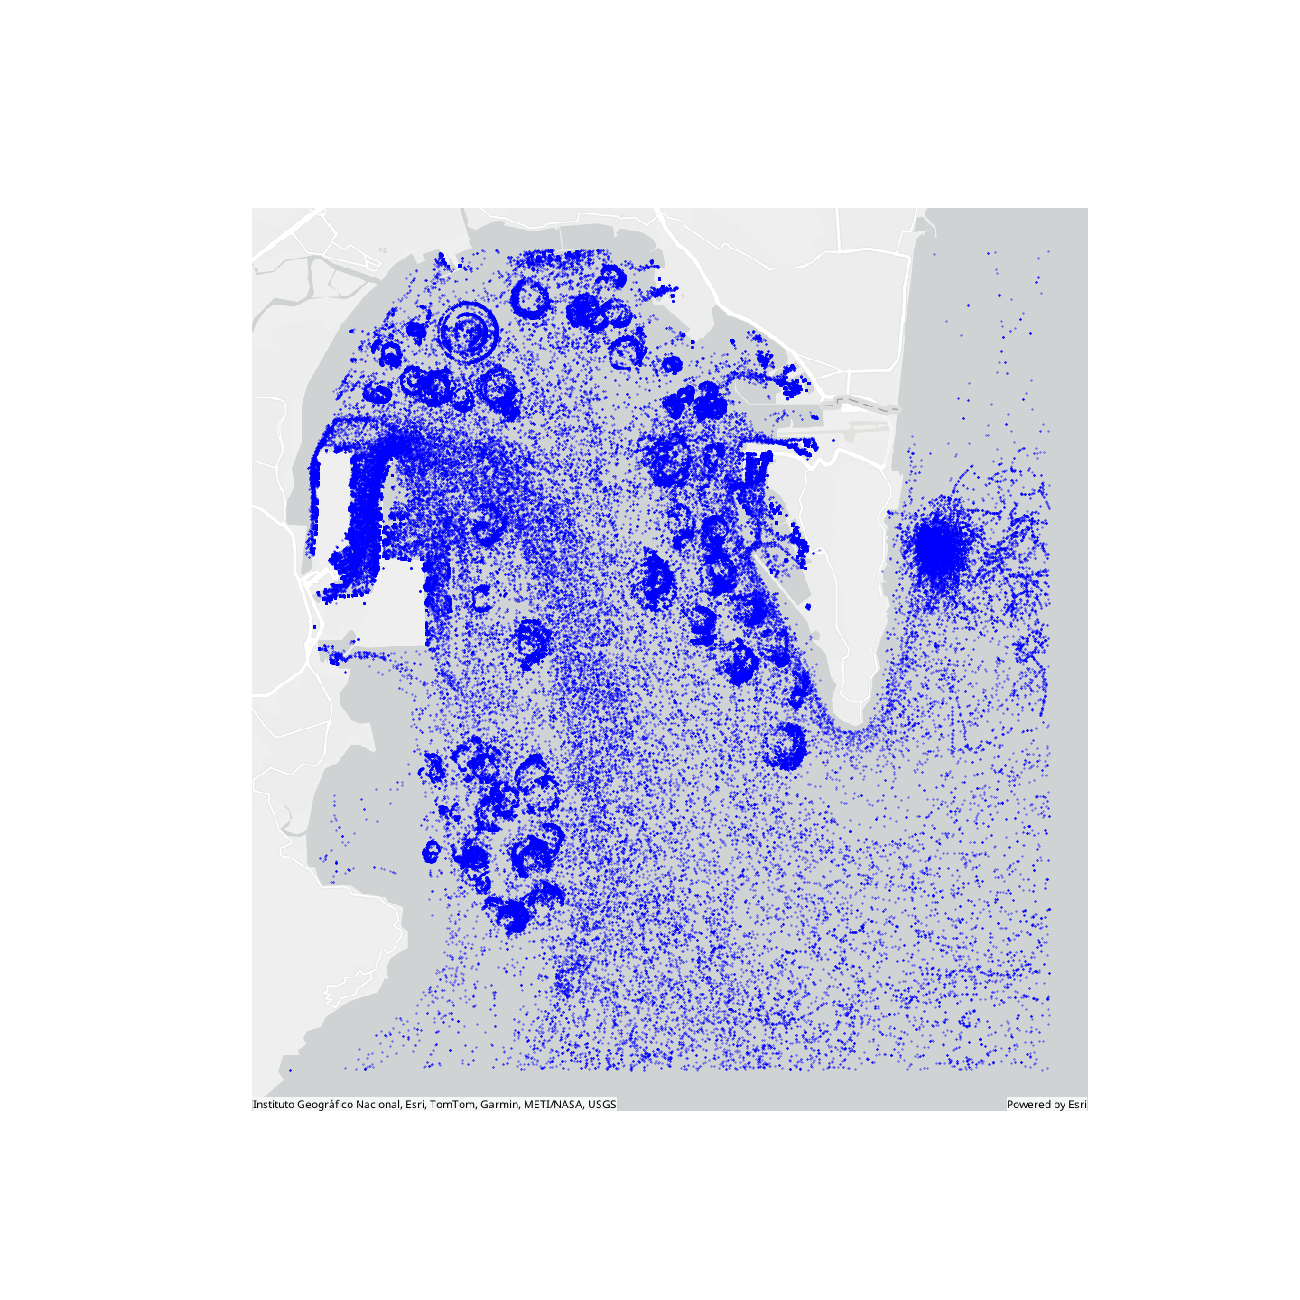

In [28]:
mapa_general_mejorado = df_proyectadas.st.plot(s=0.1,
                        facecolor="blue",
                        figsize=(13, 13), 
                        legend=True, 
                        legend_kwds={"label": "Total posiciones barcos"},
                        basemap="light")

mapa_general_mejorado.set(xlim=(-607588.9895384323, -590124.1438954463), 
         ylim=(4307100.0, 4326900.0), 
         frame_on=False,
         xticks=[],
         yticks=[])

%matplot plt

## 🫂 Agrupación de los datos

In [29]:
from geoanalytics.tools import AggregatePoints

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

La función Agregar puntos resume los puntos en polígonos o contenedores. Los límites de los polígonos o contenedores se utilizan para recopilar los puntos dentro de cada área y utilizarlos para calcular estadísticas. El resultado siempre contiene el recuento de puntos dentro de cada área.

<img src='https://developers.arcgis.com/geoanalytics/static/28c8db9e9fc3d358a461c078ecc55427/0c69d/ap-workflow.png' width='500px' />

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

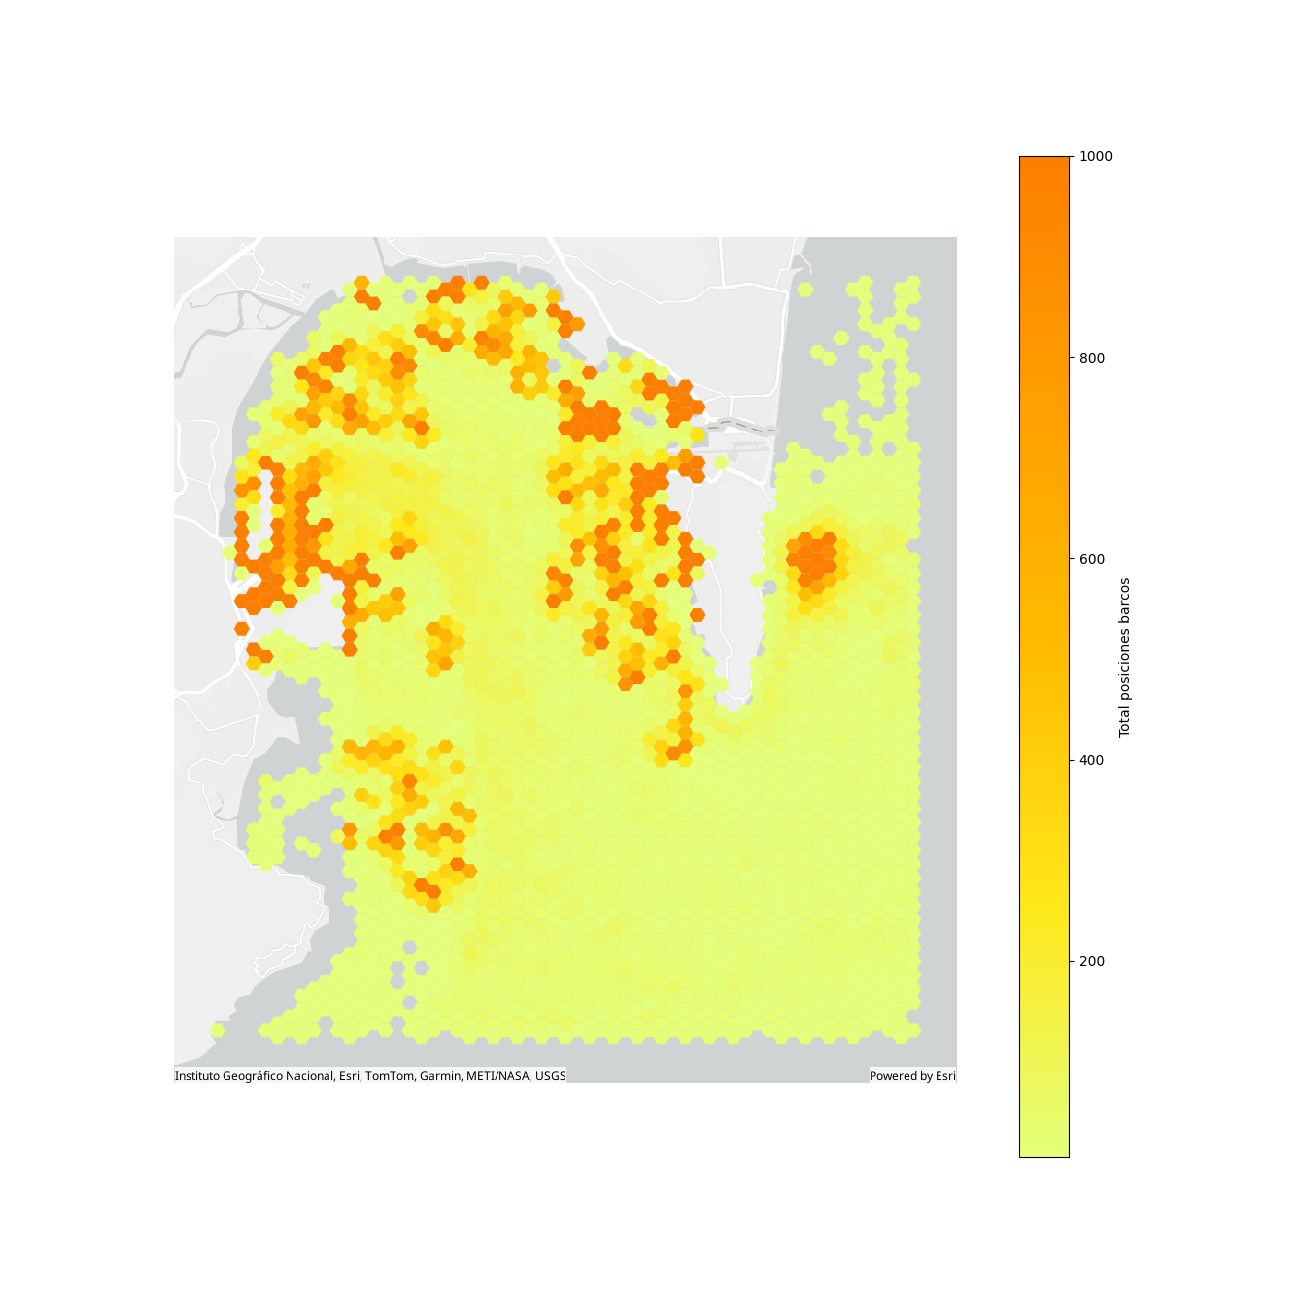

In [31]:
agregation = AggregatePoints().setBins(bin_size=300, bin_size_unit="Meters",bin_type="Hexagon").run(df_proyectadas)

agregation_plot = agregation.st.plot(cmap_values="COUNT", 
                      cmap="Wistia", 
                      vmax=1000, 
                      vmin=5, 
                      figsize=(13, 13), 
                      legend=True, 
                      legend_kwds={"label": "Total posiciones barcos"},
                      basemap="light")

agregation_plot.set(xlim=(-607588.9895384323, -590124.1438954463), 
         ylim=(4307100.0, 4326900.0), 
         frame_on=False, xticks=[], yticks=[])

%matplot plt

# 📐 Análisis geoespacial

In [32]:
df_2908 = df_proyectadas.filter(F.to_date("timestamp") == "2022-08-29")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [33]:
rows = df_2908.count()
print(f"Numero de filas : {rows:,}")
cols = len(df_2908.columns)
print(f"Numero de columnas : {cols}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Numero de filas : 638,376
Numero de columnas : 24

Fijaros que hemos pasado de **2.487.732** registros a **638.376**

## 🌌 Reconstrucción de rutas

In [34]:
from geoanalytics.tools import ReconstructTracks

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Reconstruct Tracks conecta puntos secuenciales en el tiempo en rutas y resume los registros dentro de la ruta. Las rutas se identifican mediante uno o varios campos. El DataFrame resultante contiene la ruta como una cadena de líneas o un polígono, el recuento de registros dentro de una ruta que se han resumido y cualquier estadística adicional que se haya especificado.

<img src='https://developers.arcgis.com/geoanalytics/static/bfb519af0da08ce698cbd9300b3bc786/77edc/rt-workflow.png' width='500px'/>

In [35]:
tracks = ReconstructTracks()\
    .setTrackFields("mmsi").setDistanceMethod(distance_method="Geodesic")\
    .setTimeBoundarySplit(time_boundary_split=1, time_boundary_split_unit='Hours', time_boundary_reference=None)\
    .run(dataframe=df_2908)

rows = tracks.count()
print(f"\033[1mTotal rutas: {rows:,}\033[0m")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Total rutas: 5,109

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

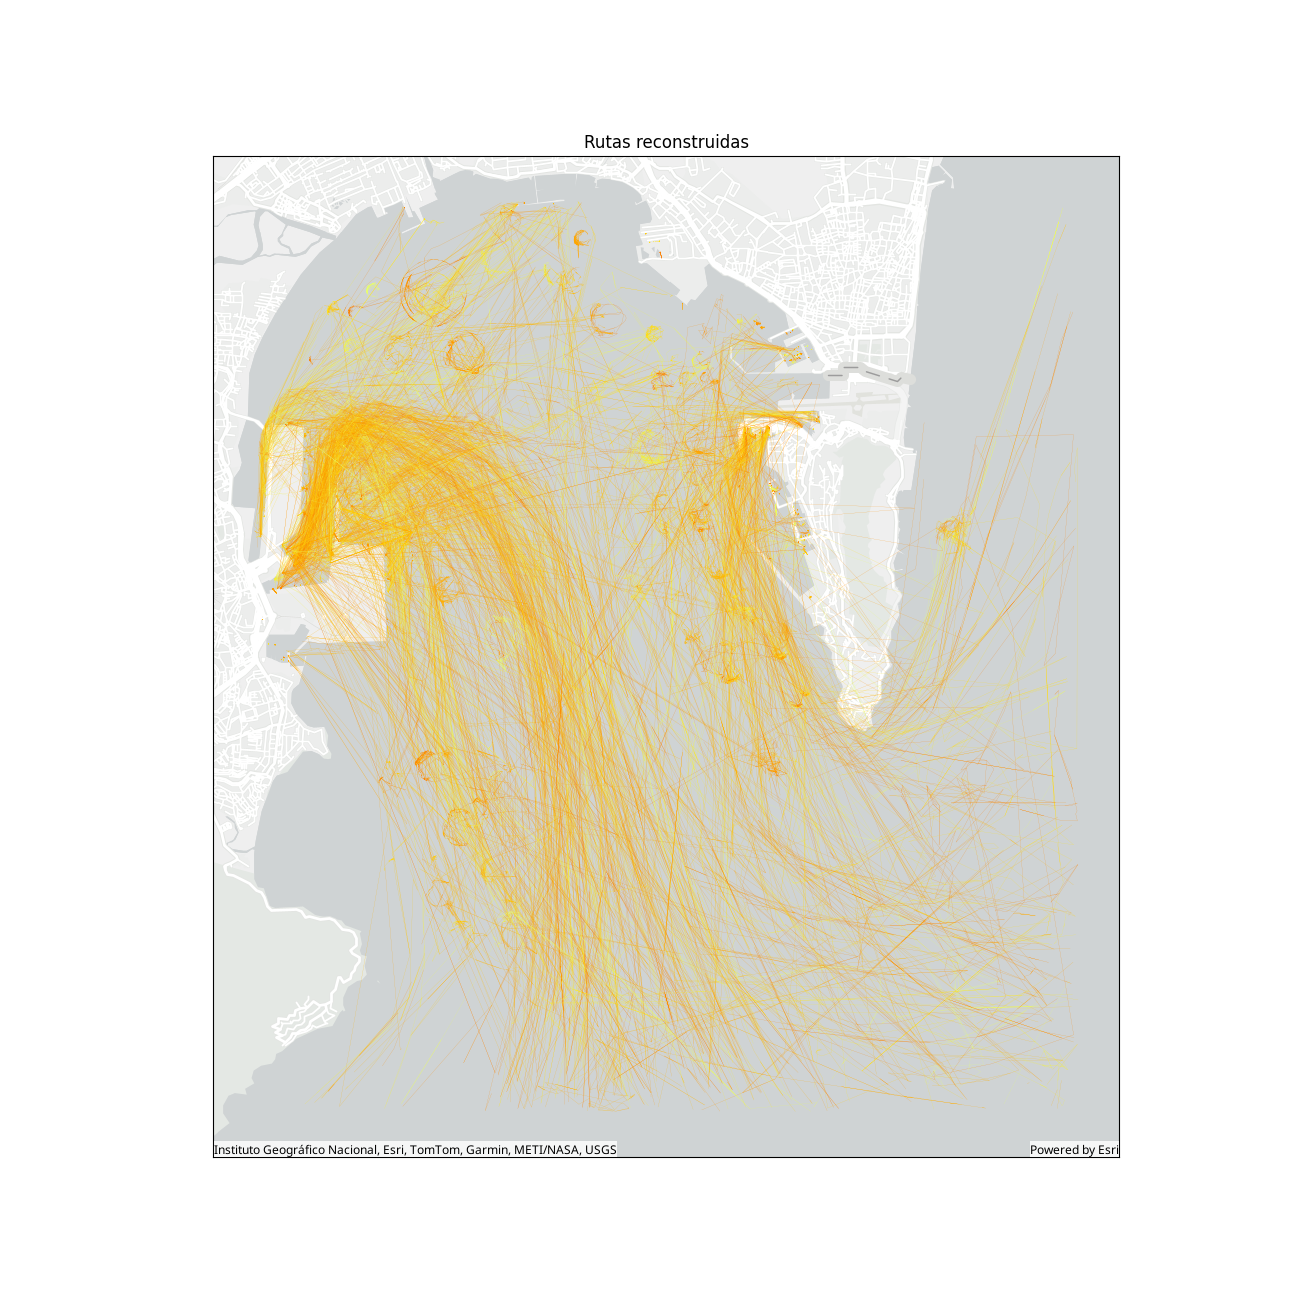

In [36]:
rutas_plot = tracks.st.plot(cmap_values="mmsi",
                            linewidth=0.1,
                            is_categorical=True,
                            cmap="Wistia",
                            legend=False,
                            legend_kwds={
                                "title": "User ID",
                                "loc": "lower left",
                                "bbox_to_anchor": (0, 0.03)
                            },
                            figsize=(13, 13),
                            basemap="light")

plt.title("Rutas reconstruidas")
plt.xticks([])
plt.yticks([])

%matplot plt

### 📡 Rutas y posiciones de los barcos en la Bahía

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

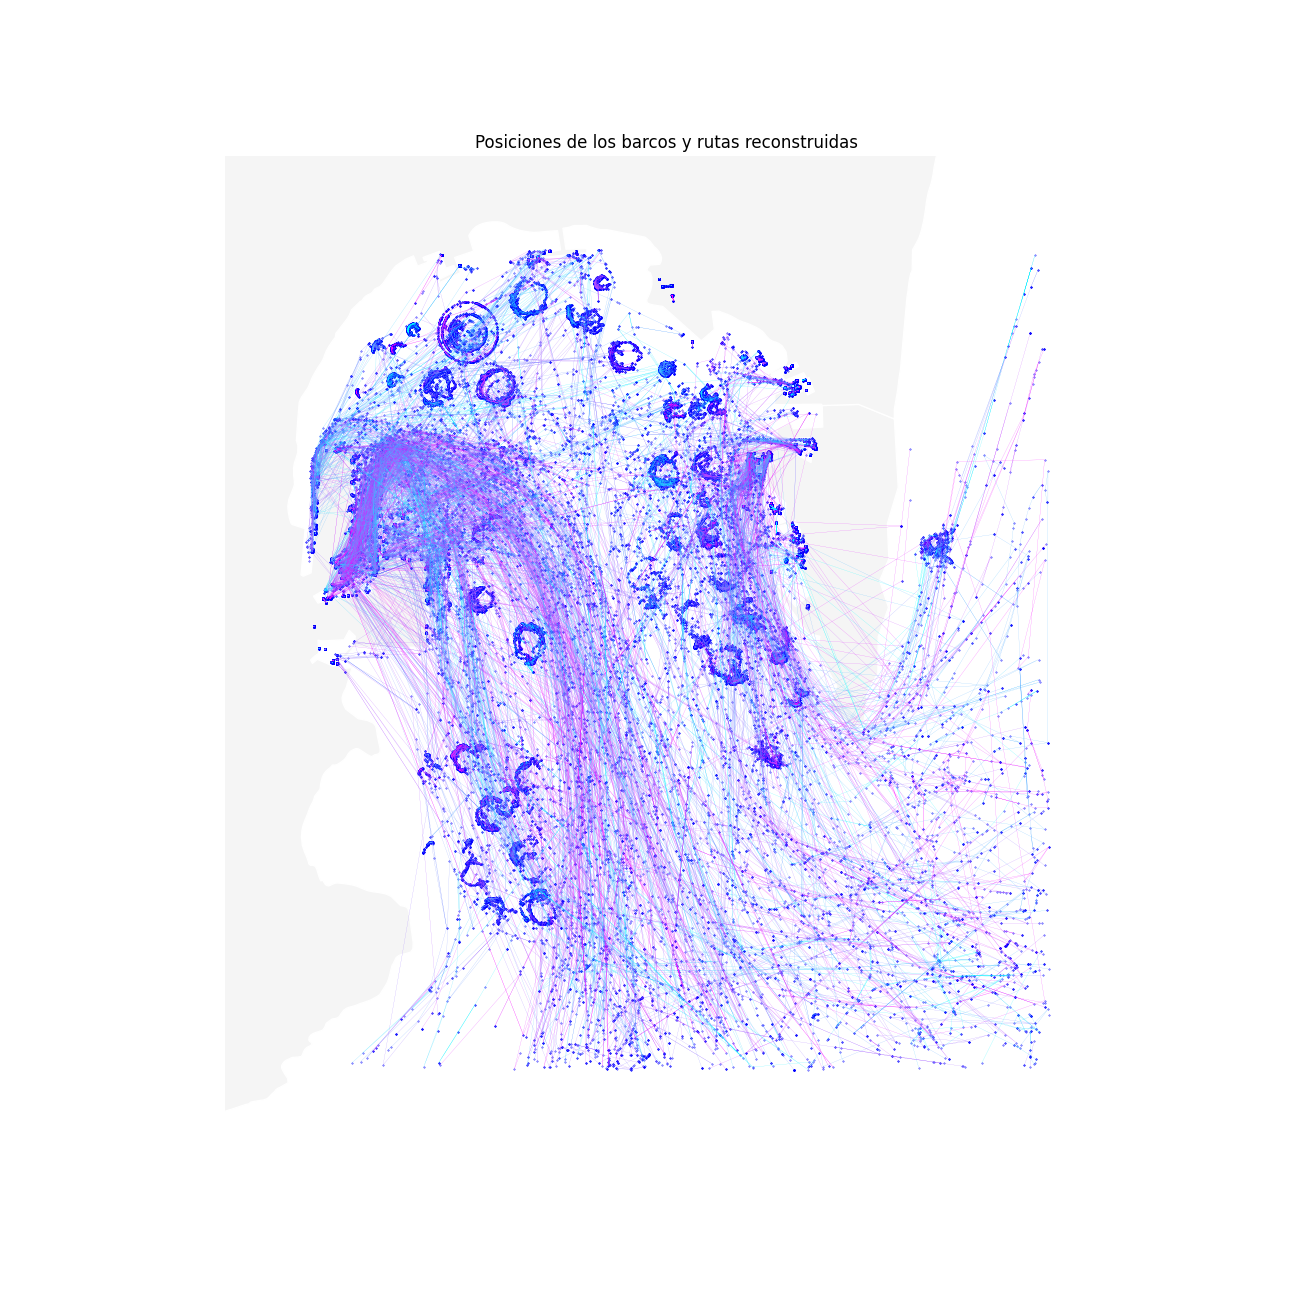

In [37]:
fig, ax = plt.subplots(figsize=(13, 13))


url = "https://services.arcgis.com/P3ePLMYs2RVChkJx/ArcGIS/rest/services/World_Countries/FeatureServer/0"
basemap = spark.read.format("feature-service").load(url)

basemap.st.plot(
    ax=ax,
    facecolor="whitesmoke", 
    edgecolor="white"
)

# Rutas
tracks.st.plot(
    ax=ax,                
    cmap_values="mmsi",
    linewidth=0.1,
    is_categorical=True,
    cmap="cool",
    legend=False
)

# Posiciones
df_2908.st.plot(
    ax=ax,                
    s=0.1,
    facecolor="blue",
    legend=False
)


# Ajustes estéticos
ax.set_xlim(-607588.9895384323, -590124.1438954463)
ax.set_ylim(4307100.0, 4326900.0)
ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])

plt.title("Posiciones de los barcos y rutas reconstruidas")


%matplot plt

## 😴 Find dwell locations

In [39]:
from geoanalytics.tools import FindDwellLocations

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

La función Find dwell Locations determina las ubicaciones de permanencia a partir de puntos secuenciales en el tiempo en una ruta. Las ubicaciones de permanencia se definen como observaciones secuenciales con poco o ningún movimiento durante un determinado periodo de tiempo.

<img src='https://developers.arcgis.com/geoanalytics/static/4d8d3ac3303aee13167ffc5c9ab51835/8f2fb/fdl-workflow.png' width='400px' />

In [54]:
dwell_locations = FindDwellLocations() \
            .setTrackFields("mmsi") \
            .setDistanceMethod(distance_method="Planar") \
            .setDwellMaxDistance(max_distance=70, max_distance_unit="Meters") \
            .setDwellMinDuration(min_duration=5, min_duration_unit="Minutes") \
            .setOutputType(output_type='DwellConvexHulls') \
            .run(dataframe=df_2908)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

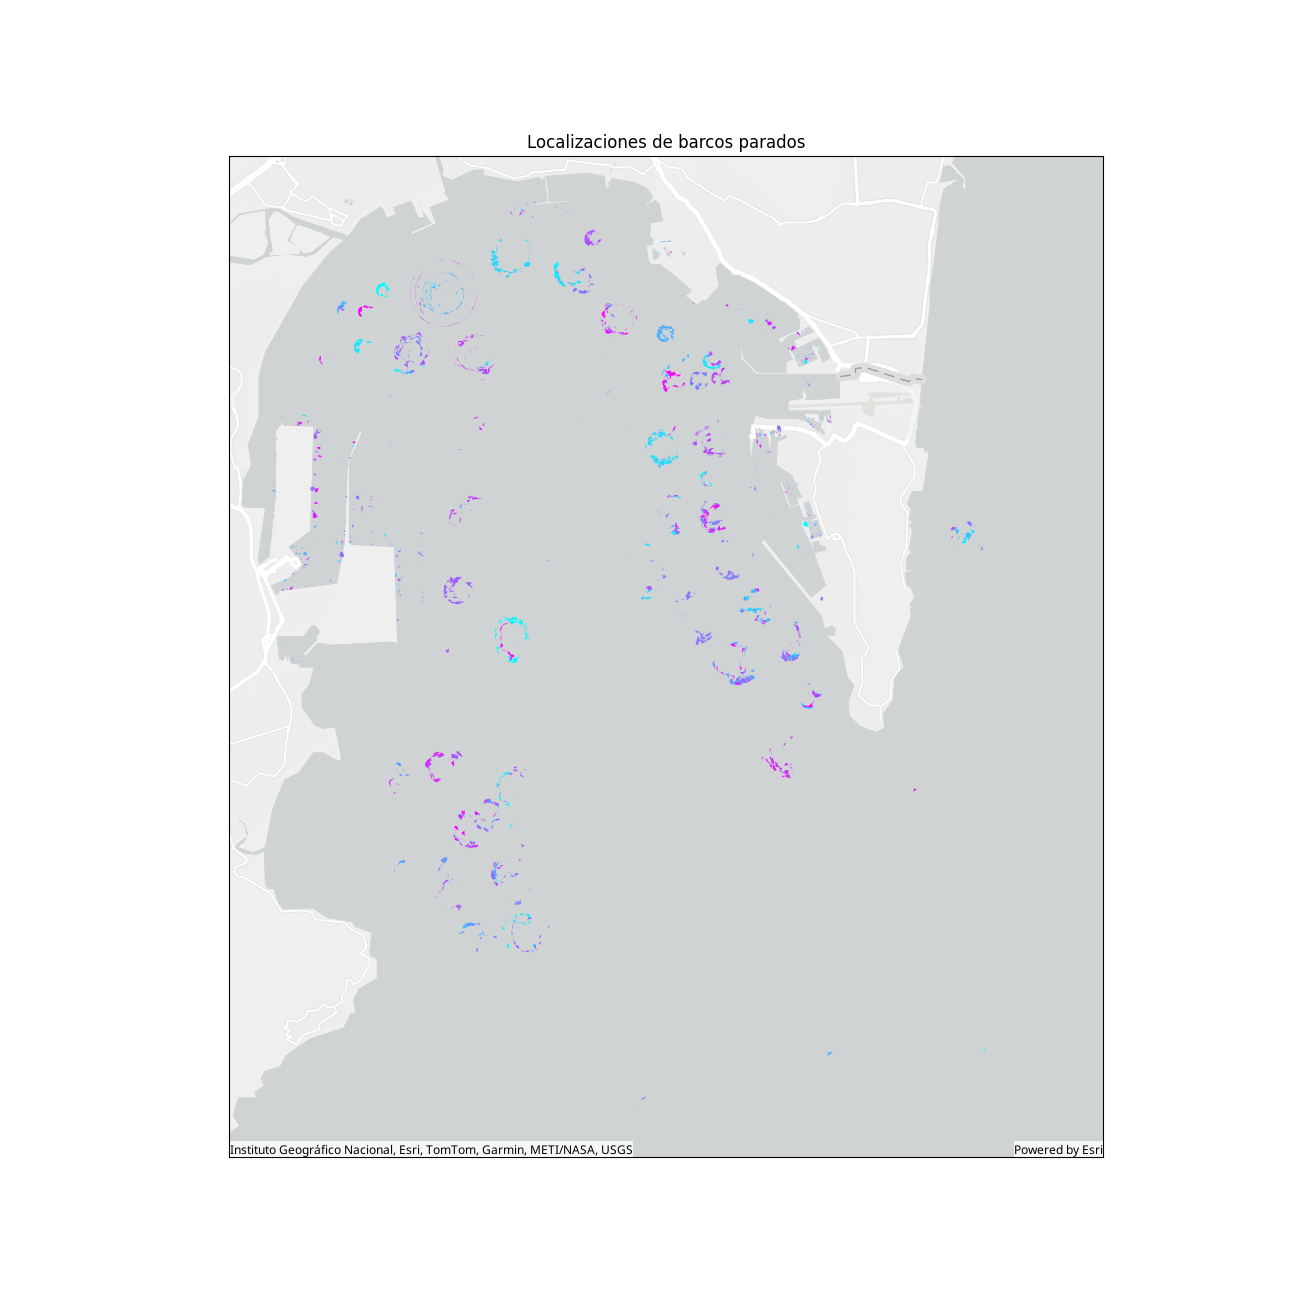

In [59]:
dwell_locations.st.plot(basemap='light',figsize=(13, 13),cmap_values="mmsi",cmap="cool")

plt.title("Localizaciones de barcos parados")
plt.xticks([])
plt.yticks([])

%matplot plt

## 🔍 Inspección más a fondo

In [134]:
from geoanalytics.sql import functions as ST, Polygon

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Creamos un polígono para hacer un filtro espacial

<img src='https://developers.arcgis.com/javascript/latest/assets/img/apiref/layers/spatialRelationships/intersects.png' />

In [135]:
# Creamos un dataframe con un polígono cerrado

data = [
    ("POLYGON((-5.3450202 36.105791, -5.321331 36.10579, -5.321331 36.153209, -5.345020 36.1532, -5.345020 36.105791))",)
]

polygon_df = spark.createDataFrame(data, ["wkt"])
polygon_df = polygon_df.withColumn("geometry", ST.geom_from_text("wkt", sr=4326))
polygon_df = polygon_df.drop("wkt")


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [136]:
join_polygon = df_proyectadas.join(polygon_df)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [172]:
join_polygon.show(1, truncate=False, vertical=True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

-RECORD 0-------------------------------------------------------------------------------------------------------------------------------------------------------------
 created_at          | 2022-09-01 09:28:19.917002 UTC                                                                                                                 
 timestamp           | 2022-09-01 09:28:19                                                                                                                            
 static_updated_at   | NULL                                                                                                                                           
 position_updated_at | 2022-09-01 09:28:19 UTC                                                                                                                        
 mmsi                | 970020804                                                                                                                                     

In [140]:
intersects = join_polygon.withColumn("Intersects", ST.intersects("SHAPE","geometry"))

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [142]:
df_spatially_filtered = intersects.filter(intersects["Intersects"] == True)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

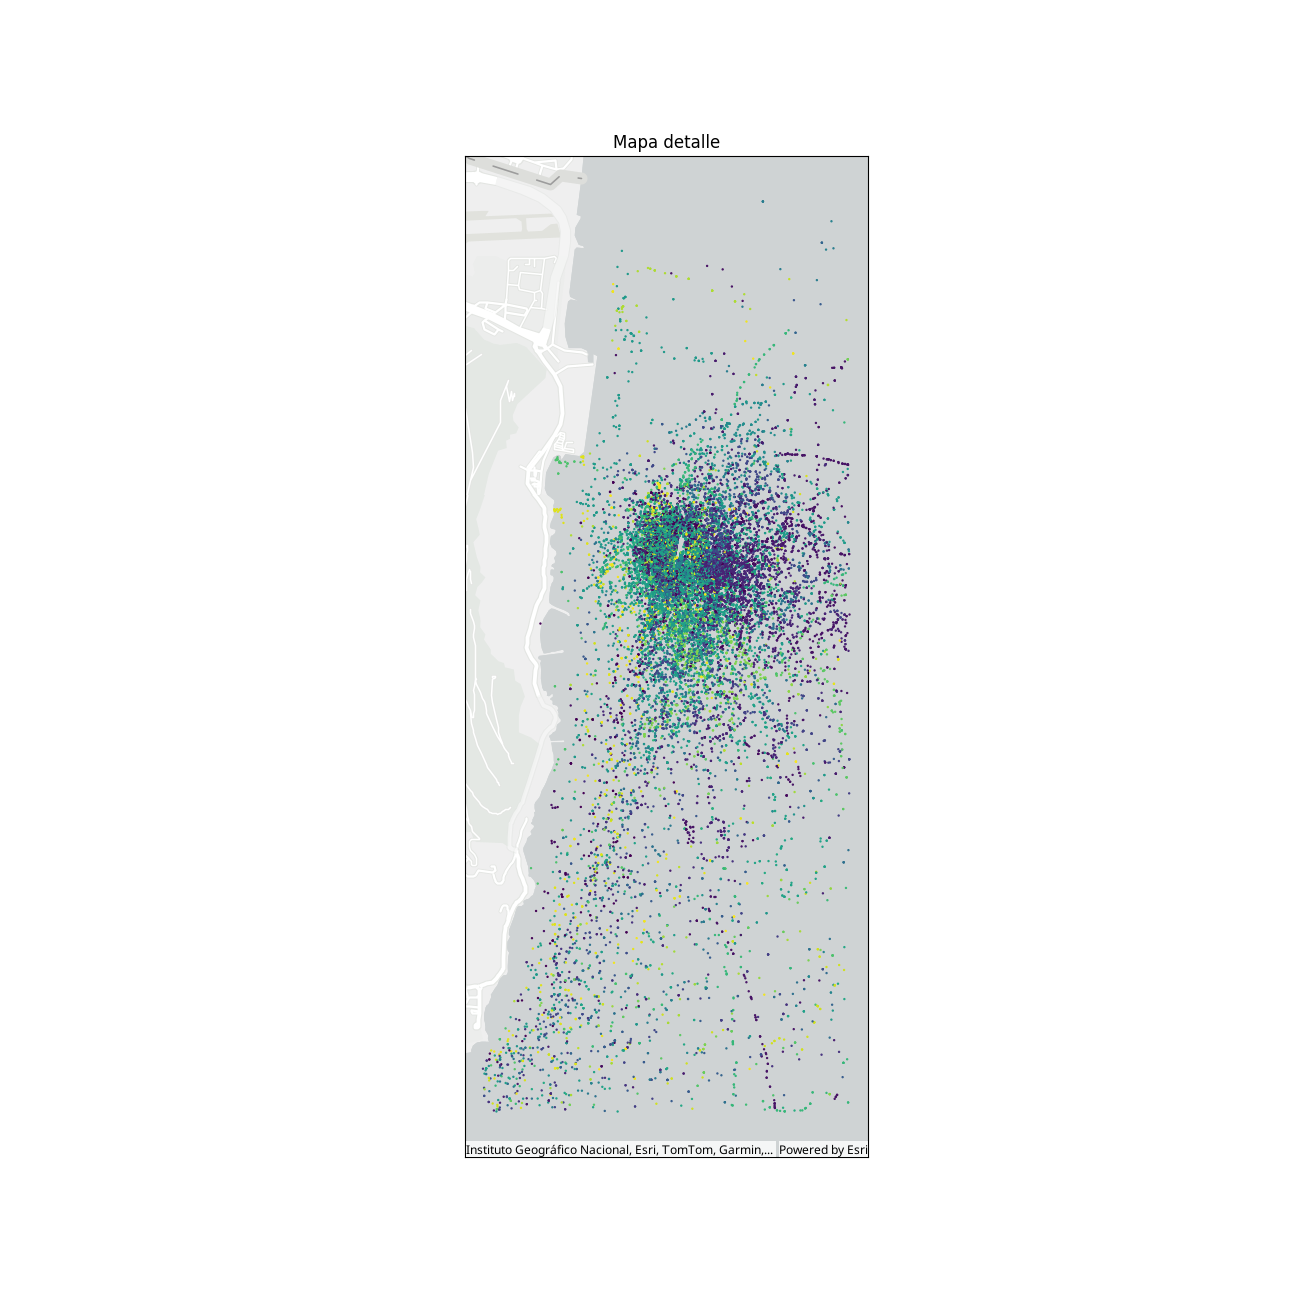

In [171]:
mapa_detalle = df_spatially_filtered.st.plot(geometry='SHAPE',basemap='light',figsize=(13, 13),s=0.5,
                        cmap_values="mmsi",)

plt.title("Mapa detalle")
plt.xticks([])
plt.yticks([])
%matplot plt

In [154]:
df_sp_filtered_count = df_spatially_filtered.groupBy("mmsi").count().toPandas()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [169]:
df_sp_filtered_count = df_sp_filtered_count.sort_values("count", ascending=False).head(4)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

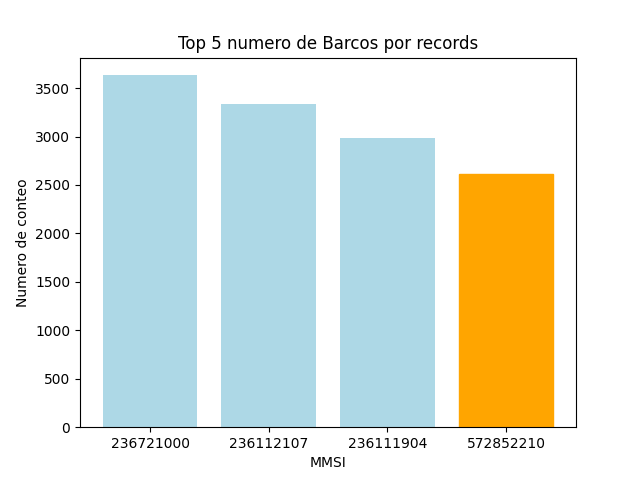

In [170]:
fig, ax = plt.subplots()


barras = plt.bar(df_sp_filtered_count["mmsi"], df_sp_filtered_count["count"],color='lightblue')
barras[3].set_color('orange')
plt.xlabel("MMSI")
plt.ylabel("Numero de conteo")
plt.title("Top 5 numero de Barcos por records")
plt.show()

%matplot plt

  <div style="display: flex; flex-direction: row; height:200px;">
    <img src="https://static.vesselfinder.net/ship-photo/9563641-236721000-0fb78569771ff8e5a26a526eff6fc93d/1?v1" style="margin: 5px;" alt="">
    <img src="https://static.vesselfinder.net/ship-photo/0-236112107-2891b08fd824a01c80e710510f2ac7a0/1?v1" style="margin: 5px;" alt="">
    <img src="https://static.vesselfinder.net/ship-photo/0-236111904-82a3a7439edf06bd2c4bbbf503194277/1?v1" style="margin: 5px;" alt="">
    <img src="https://static.vesselfinder.net/ship-photo/9172399-441116000-b47eea430051aab6bc404ed36f35d0bb/1?v1" style="margin: 5px;" alt="">
  </div>

Fuente de las imagenes: [Vessel Finder](https://www.vesselfinder.com/)

## ⚓ Investigación Buque OS35

### 🐧 Ruta del OS35

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

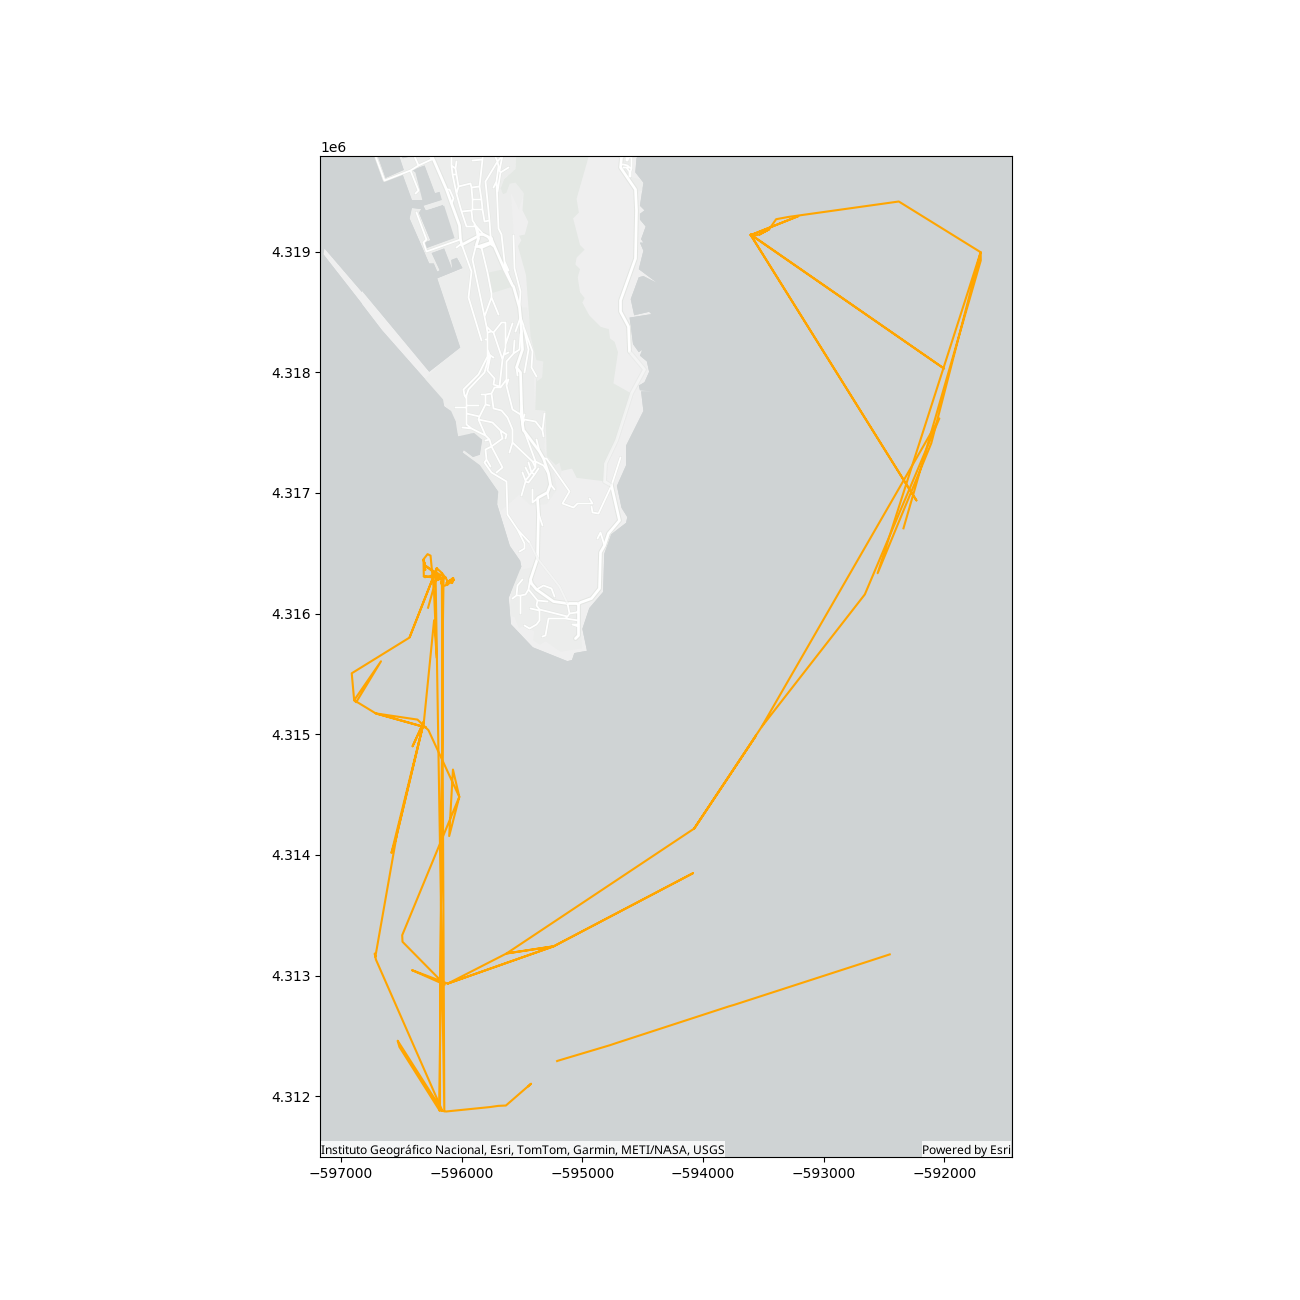

In [178]:
tracks.filter(tracks.mmsi == 572852210).st.plot(
    is_categorical=True, color="orange", figsize=(13, 13), legend=True,basemap='light')
%matplot plt

### 🤼 Análisis de proximidad

In [179]:
from geoanalytics.tools import TraceProximityEvents

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Trace Proximity Events analiza puntos temporales que representan entidades en movimiento. La herramienta sigue las entidades de interés en el espacio (ubicación) y el tiempo para ver con qué otras entidades han interactuado las entidades de interés. El rastreo continuará de entidad en entidad hasta un grado máximo configurable de separación de la entidad de interés original.

<img src='https://developers.arcgis.com/geoanalytics/static/01227a0370f0f7029e0572e401d6c4d9/d8f62/tpe-workflow.png'/>

In [180]:
result_prox = TraceProximityEvents() \
            .setEntityIdField(entity_id_field="mmsi") \
            .setEntitiesOfInterestIds(entities_of_interest_ids=
                                              [{"entityId": 572852210,  "epochTimeStamp": 1661801433000}])\
            .setDistanceMethod(distance_method="Geodesic") \
            .setSearchDuration(search_duration=10, search_duration_unit="Minutes") \
            .setSearchDistance(search_distance=200, search_distance_unit="Meters") \
            .includeTracksDataFrame() \
            .run(dataframe=df_2908)

rows = result_prox.output.count()
print(f"Total acercamientos: {rows:,}")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Total acercamientos: 107

In [181]:
result_prox.output.show(5)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+---------+---------+------------------+-----+--------------------+-------------------+
|  from_id|    to_id|  duration_minutes|depth|      event_geometry|        event_start|
+---------+---------+------------------+-----+--------------------+-------------------+
|     NULL|572852210|              NULL|    0|                NULL|2022-08-29 19:30:33|
|572852210|538005753|               0.0|    1|{"x":-596712.7312...|2022-08-29 20:16:52|
|538005753|232027022| 93.06666666666666|    2|{"x":-596693.8068...|2022-08-29 20:32:04|
|232027022|538003050|               0.0|    3|{"x":-598148.7526...|2022-08-29 20:43:40|
|538003050|224704000|1.5833333333333333|    4|{"x":-598416.4760...|2022-08-29 21:00:04|
+---------+---------+------------------+-----+--------------------+-------------------+
only showing top 5 rows

In [182]:
df_acercamientos = result_prox.output.filter(result_prox.output.depth == 1)
df_acercamientos.show()

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+---------+---------+------------------+-----+--------------------+-------------------+
|  from_id|    to_id|  duration_minutes|depth|      event_geometry|        event_start|
+---------+---------+------------------+-----+--------------------+-------------------+
|572852210|538005753|               0.0|    1|{"x":-596712.7312...|2022-08-29 20:16:52|
|572852210|236111288|162.26666666666668|    1|{"x":-593394.8537...|2022-08-29 21:13:39|
|572852210|236112137|120.23333333333333|    1|{"x":-593580.3862...|2022-08-29 21:31:41|
+---------+---------+------------------+-----+--------------------+-------------------+

  <div style="display: flex; flex-direction: row; height:200px;">
    <img src="https://static.vesselfinder.net/ship-photo/9501186-538005753-68f9e1b26f80723880d1cf0251789826/1?v1" style="margin: 5px;" alt="">
    <img src="https://static.vesselfinder.net/ship-photo/0-236111288-d62d1bf061447ec99207d2839cc5874c/1?v1" style="margin: 5px;" alt="">
    <img src="https://static.vesselfinder.net/ship-photo/0-236111904-82a3a7439edf06bd2c4bbbf503194277/1?v1" style="margin: 5px;" alt="">
  </div>


VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

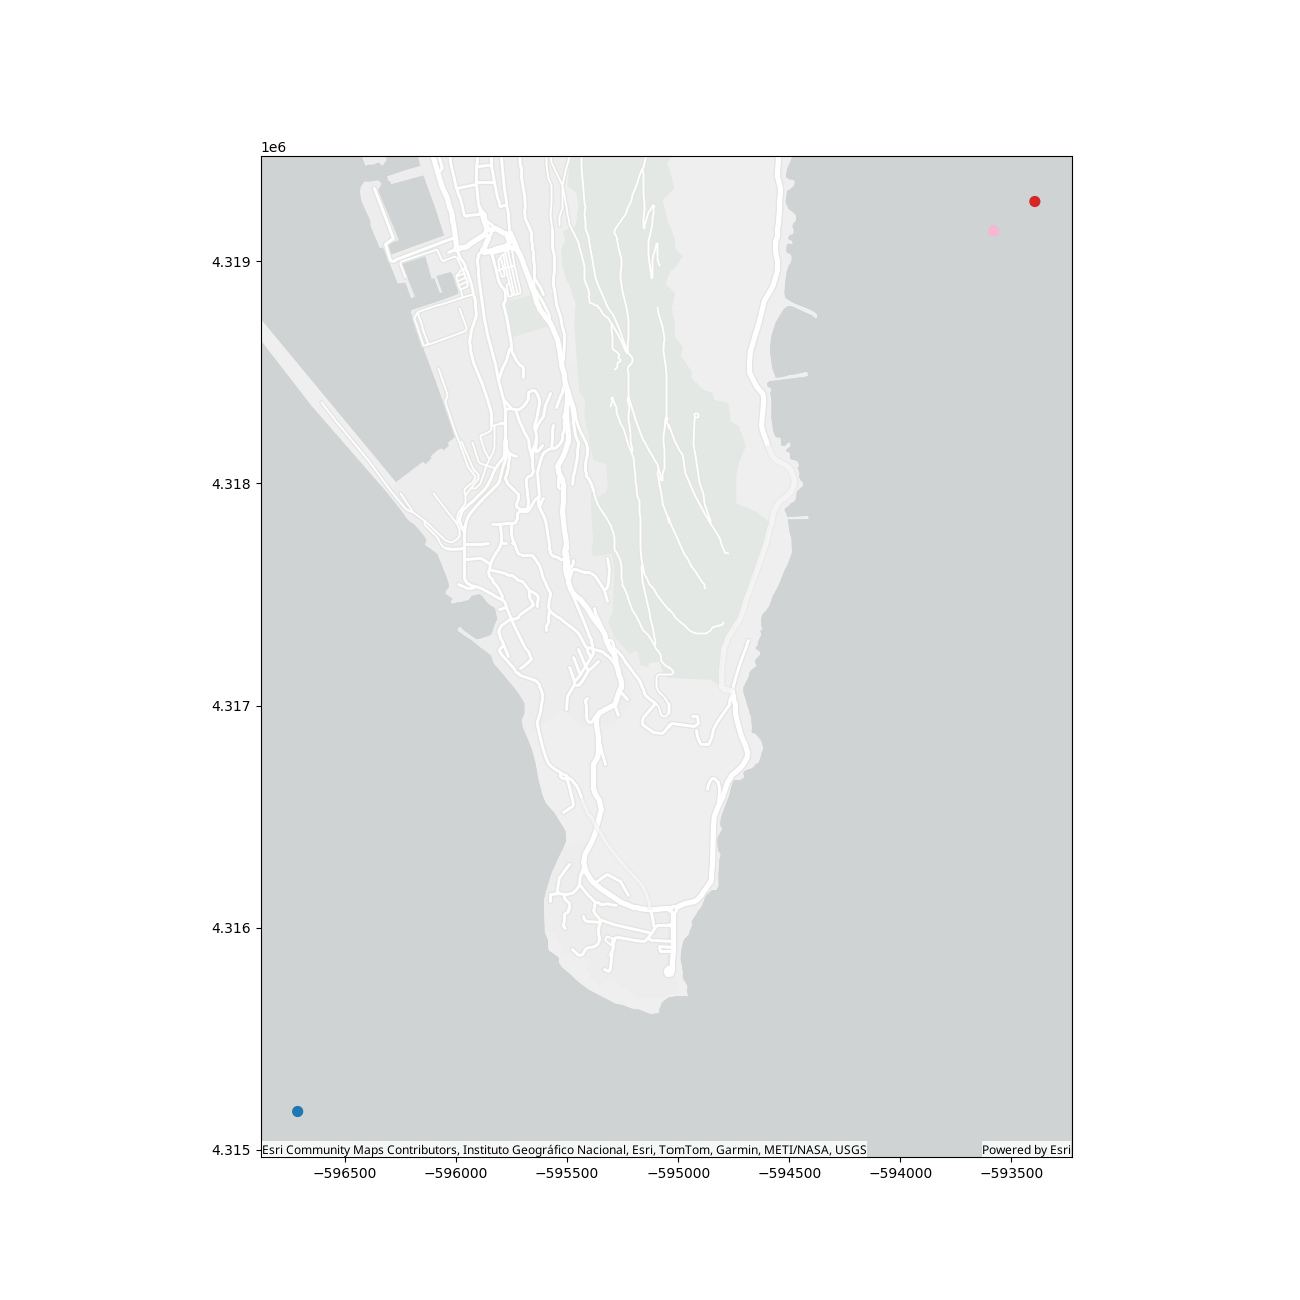

In [186]:
df_acercamientos.st.plot(is_categorical=True,cmap_values="to_id",
                           cmap="tab20",
                           s=50,
                           figsize=(13, 13),
                           basemap='light')

%matplot plt

### 🔥 Acercamiento entre OS 35 y Adam LNG

In [191]:
df_vessels = df_proyectadas.filter("mmsi == 572852210 OR mmsi == 538005753")

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [192]:
tracks_vessels = ReconstructTracks()\
    .setTrackFields("mmsi").setDistanceMethod(distance_method="Geodesic")\
    .setTimeBoundarySplit(time_boundary_split=1, time_boundary_split_unit='Hours', time_boundary_reference=None)\
    .run(dataframe=df_vessels)

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

VBox()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

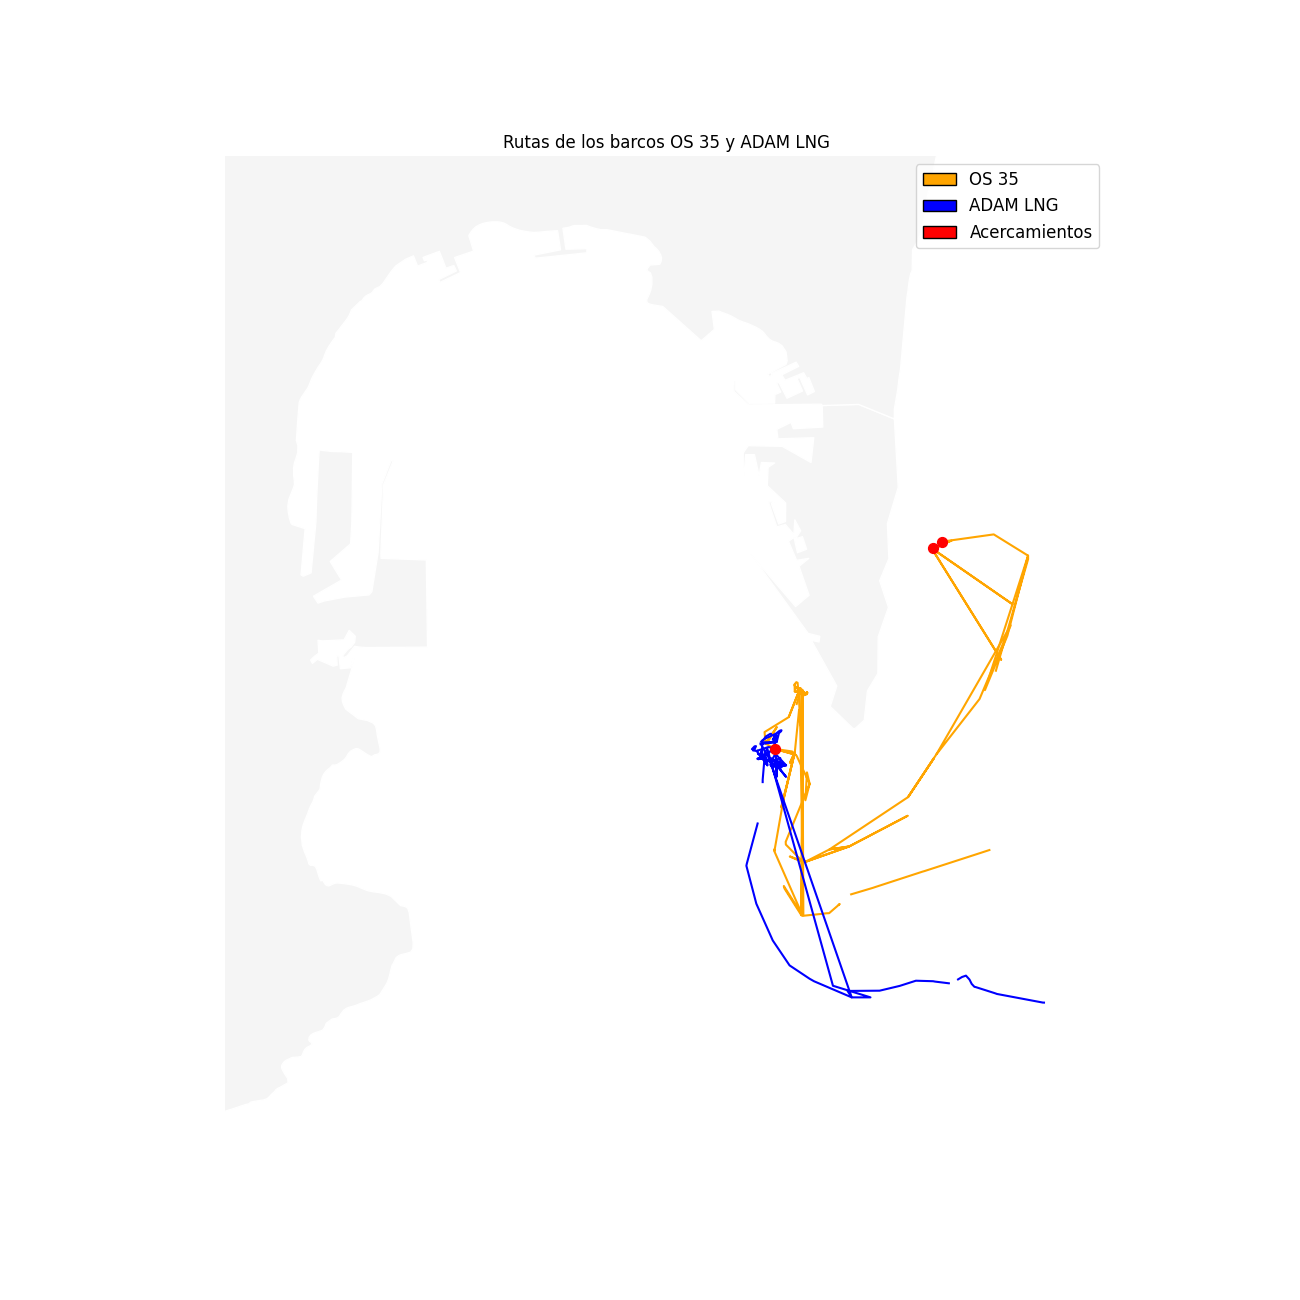

In [193]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(13, 13))

# Graficar base y acercamientos
basemap.st.plot(ax=ax, facecolor="whitesmoke", edgecolor="white")

df_acercamientos.st.plot(
    is_categorical=True,
    ax=ax,
    color="red",
    s=50,
    zorder=10,
    figsize=(13, 13),
    basemap='light'
)

# Rutas de los barcos
track_os35 = tracks.filter(tracks_vessels.mmsi == 572852210).st.plot(
    is_categorical=True, ax=ax, color="orange", figsize=(13, 13)
)
track_adamlng = tracks.filter(tracks_vessels.mmsi == 538005753).st.plot(
    is_categorical=True, ax=ax, color="blue", figsize=(13, 13)
)

# Ajustes estéticos
ax.set_xlim(-607588.9895384323, -590124.1438954463)
ax.set_ylim(4307100.0, 4326900.0)
ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])

# Leyenda manual
legend_elements = [
    Patch(facecolor='orange', edgecolor='black', label='OS 35'),
    Patch(facecolor='blue', edgecolor='black', label='ADAM LNG'),
    Patch(facecolor='red', edgecolor='black', label='Acercamientos')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.title("Rutas de los barcos OS 35 y ADAM LNG")
%matplot plt

## 🧠 Recap y Conclusiones

En este análisis hemos podido ver como podemos utilizar herramientas comunes de entornos Big Data para analizar gran cantidades de datos geoespaciales y temporales.
- Hemos utilizado Apache Spark dentro de un entorno AWS en EMR para poder paralelizar el procesamiento de los datos.
- Hemos utilizado ArcGIS

- Los datos nos pueden informar sobre qué sucede antes que los informes oficiales.
- Los datos geoespaciales nos permiten entender mejor qué sucede gracias a la representación.
- Los gráficos y tablas resumen aportan mucha información pero se ve complementada con los mapas.
- Los datos geográficos se han de tratar con herramientas específicas para ello.